
<a href="https://colab.research.google.com/github/akshayas002/practice/blob/main/time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
stock = yf.download("AAPL", start="2015-01-01", end="2023-01-01")
print(stock.head())

/tmp/ipykernel_12070/1913925215.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("AAPL", start="2015-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-01-02  24.214891  24.682224  23.776352  24.671149  212818400
2015-01-05  23.532721  24.064284  23.346674  23.984549  257142000
2015-01-06  23.534939  23.794075  23.173918  23.596954  263188400
2015-01-07  23.864943  23.964610  23.632383  23.743125  160423600
2015-01-08  24.781897  24.839483  24.075361  24.192749  237458000


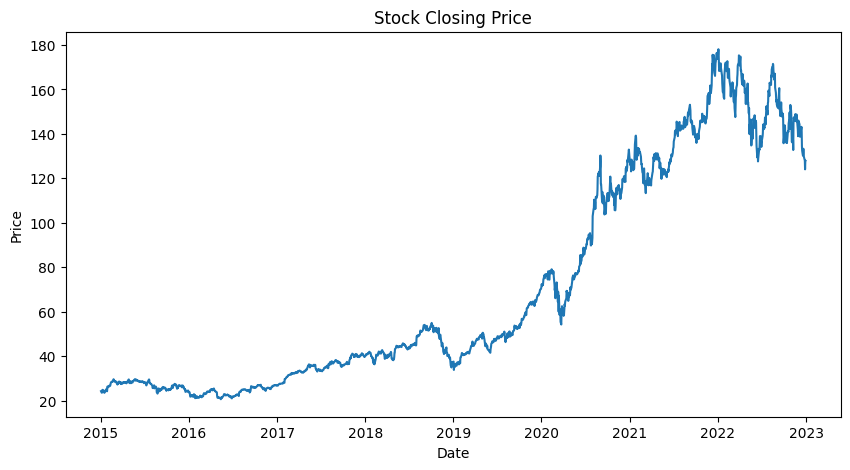

In [3]:
plt.figure(figsize=(10,5))
plt.plot(stock['Close'])
plt.title("Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

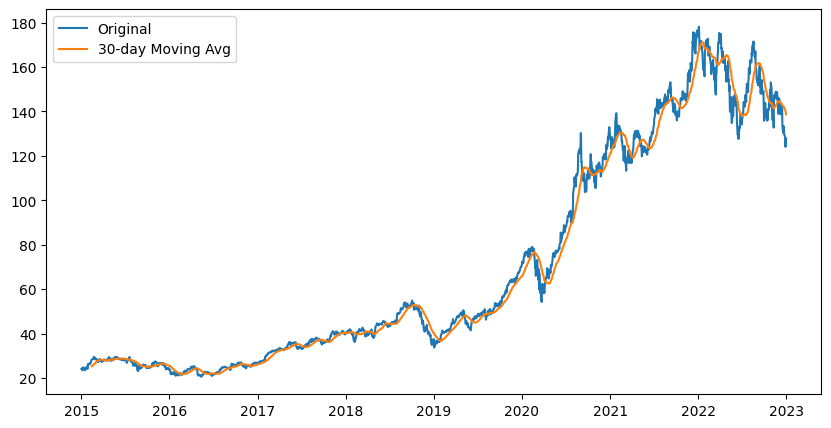

In [4]:
stock['Rolling_Mean'] = stock['Close'].rolling(window=30).mean()
plt.figure(figsize=(10,5))
plt.plot(stock['Close'], label='Original')
plt.plot(stock['Rolling_Mean'], label='30-day Moving Avg')
plt.legend()
plt.show()

ADF Statistic: -0.6303074195855226
p-value: 0.8639856969853505


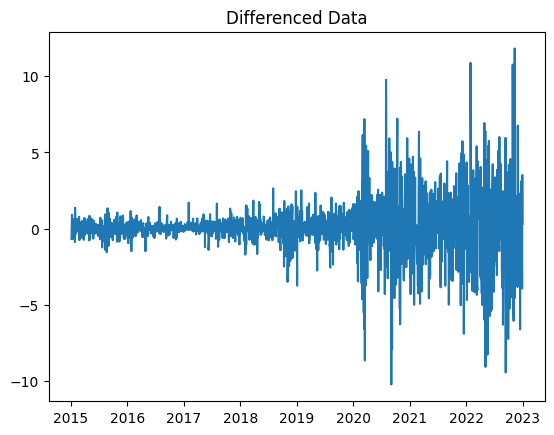

In [5]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(stock['Close'].dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])
stock['Diff'] = stock['Close'] - stock['Close'].shift(1)
plt.plot(stock['Diff'])
plt.title("Differenced Data")
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   AAPL   No. Observations:                 2014
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -3955.105
Date:                Wed, 08 Apr 2026   AIC                           7922.209
Time:                        09:26:40   BIC                           7955.854
Sample:                             0   HQIC                          7934.559
                               - 2014                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0580      0.013     -4.544      0.000      -0.083      -0.033
ar.L2         -0.0291      0.013     -2.262      0.024      -0.054      -0.004
ar.L3         -0.0312      0.014     -2.176      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


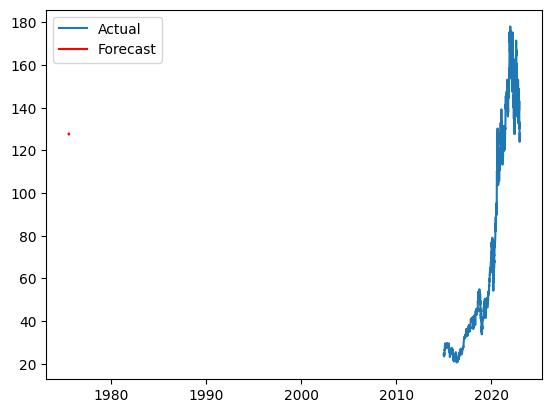

In [6]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(stock['Close'], order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())
forecast = model_fit.forecast(steps=10)
print("Forecasted Prices:\n", forecast)
plt.plot(stock['Close'], label='Actual')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.show()